In [1]:
# 11.4 Q1 - Real-Estate PCA (Maggie's Problem)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('datasets/real_estate.csv')
print("Shape:", df.shape)
print(df.head())
print()
print("Columns:", list(df.columns))

Shape: (20640, 10)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  months_unsold  
0    -122.23        4.526              3  
1    -122.22        3.585             11  
2    -122.24        3.521              9  
3    -122.25        3.413              7  
4    -122.25        3.422              7  

Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal', 'months_unsold']


In [4]:
y = df['months_unsold']
X = df.drop(columns=['months_unsold'])
print("Features:", list(X.columns))
print()
print("y distribution:")
print(y.describe().round(2))

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

y distribution:
count    20640.00
mean         6.45
std          3.59
min          0.00
25%          3.00
50%          6.00
75%          9.00
max         13.00
Name: months_unsold, dtype: float64


In [5]:
sc = StandardScaler()
X_s = sc.fit_transform(X)
print("Standardised shape:", X_s.shape)
print("Mean per feature (approx 0):", X_s.mean(axis=0).round(3)[:4])
print("Std  per feature (1)      :", X_s.std(axis=0).round(3)[:4])

Standardised shape: (20640, 9)
Mean per feature (approx 0): [ 0.  0.  0. -0.]
Std  per feature (1)      : [1. 1. 1. 1.]


In [6]:
# Apply PCA - keep all components

In [7]:
pca = PCA()
X_pca = pca.fit_transform(X_s)

evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)
print("Explained variance ratio per PC:")
for i, (e, c) in enumerate(zip(evr, cum), 1):
    print("  PC%2d: %.4f  cumulative = %.4f" % (i, e, c))

n95 = int(np.argmax(cum >= 0.95) + 1)
print()
print("Components for 95% variance:", n95)

Explained variance ratio per PC:
  PC 1: 0.2263  cumulative = 0.2263
  PC 2: 0.2195  cumulative = 0.4458
  PC 3: 0.1791  cumulative = 0.6249
  PC 4: 0.1411  cumulative = 0.7660
  PC 5: 0.1115  cumulative = 0.8774
  PC 6: 0.0769  cumulative = 0.9543
  PC 7: 0.0337  cumulative = 0.9881
  PC 8: 0.0071  cumulative = 0.9951
  PC 9: 0.0049  cumulative = 1.0000

Components for 95% variance: 6


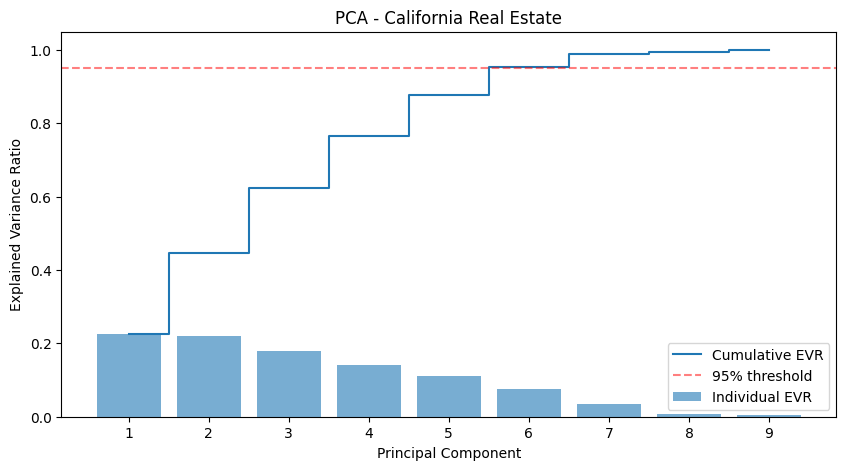

In [8]:
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(evr)+1), evr, alpha=0.6, label='Individual EVR')
plt.step(range(1, len(cum)+1), cum, where='mid', label='Cumulative EVR')
plt.axhline(0.95, color='red', linestyle='--', alpha=0.5, label='95% threshold')
plt.xticks(range(1, len(evr)+1))
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA - California Real Estate')
plt.legend()
plt.show()

In [9]:
# 2-D PCA scatter colored by months_unsold

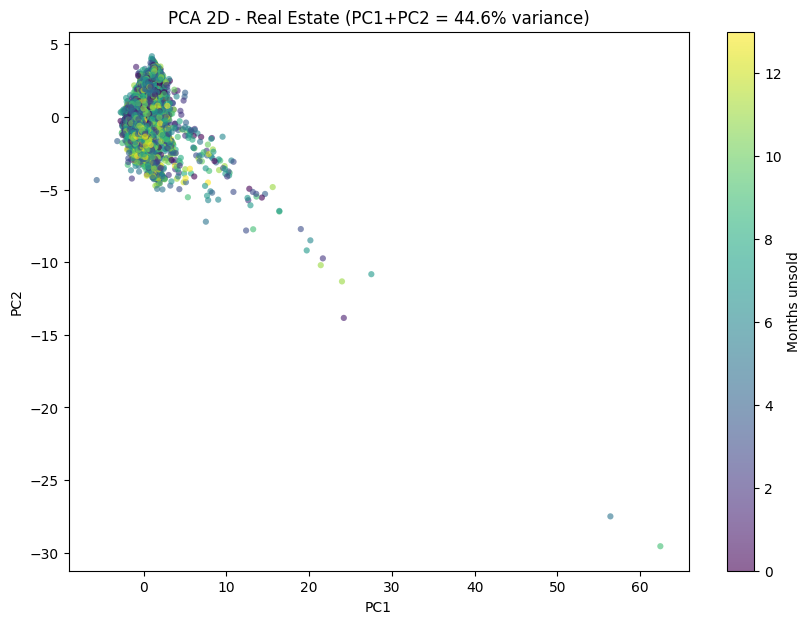

In [10]:
plt.figure(figsize=(10, 7))
sc_p = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis',
                    s=20, alpha=0.6, edgecolors='none')
plt.colorbar(sc_p, label='Months unsold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D - Real Estate (PC1+PC2 = ' + str(round((evr[0]+evr[1])*100, 1)) + '% variance)')
plt.show()

In [11]:
# Feature Loadings on PC1 & PC2

                  PC1       PC2
AveRooms     0.560200 -0.315956
AveBedrms    0.470478 -0.207376
Latitude     0.423629  0.526459
Longitude   -0.408498 -0.501717
MedInc       0.247805 -0.398949
MedHouseVal  0.184442 -0.352991
Population  -0.145947 -0.118776
HouseAge    -0.039065  0.174391
AveOccup    -0.015506 -0.002345


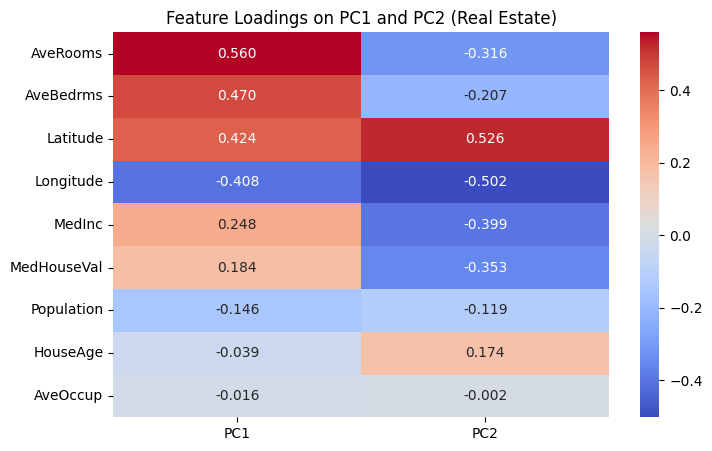

In [12]:
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=X.columns,
    columns=['PC1', 'PC2']
).sort_values('PC1', ascending=False, key=abs)
print(loadings)

plt.figure(figsize=(8, 5))
sns.heatmap(loadings, cmap='coolwarm', annot=True, fmt='.3f')
plt.title('Feature Loadings on PC1 and PC2 (Real Estate)')
plt.show()

In [13]:
# Top-3 features contributing to PC1

In [14]:
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(3)
print("Top-3 features contributing to PC1:")
for f, w in top_pc1.items():
    sign = '+' if loadings.loc[f, 'PC1'] > 0 else '-'
    print("  " + f.ljust(20), "(" + sign + str(round(abs(w), 3)) + ")")

Top-3 features contributing to PC1:
  AveRooms             (+0.56)
  AveBedrms            (+0.47)
  Latitude             (+0.424)
